# Example execution

This part of the code is created to explore the results of the program as well as to evaluate mistakes in model predictions.

In [1]:
import torch
import numpy as np

import cv2
import matplotlib.pyplot as plt

import os

In [2]:
model = torch.jit.load("yoga_gcn.pt")
model.eval()


RecursiveScriptModule(
  original_name=YogaGCN
  (conv1): RecursiveScriptModule(
    original_name=GCNConv
    (aggr_module): RecursiveScriptModule(original_name=SumAggregation)
    (lin): RecursiveScriptModule(original_name=Linear)
  )
  (conv2): RecursiveScriptModule(
    original_name=GCNConv
    (aggr_module): RecursiveScriptModule(original_name=SumAggregation)
    (lin): RecursiveScriptModule(original_name=Linear)
  )
  (ln1): RecursiveScriptModule(original_name=LayerNorm)
  (ln2): RecursiveScriptModule(original_name=LayerNorm)
  (lin1): RecursiveScriptModule(original_name=Linear)
  (lin2): RecursiveScriptModule(original_name=Linear)
  (dropout): RecursiveScriptModule(original_name=Dropout)
)

In [3]:
data = np.load("gcn_dataset_test.npz", allow_pickle=True)

X = data["node_features"]      # shape (N, 23, 6)
edge_index_np = data["edges"]  # shape (16, 2)
y = data["labels"]
img_names = data["img_names"]


In [4]:
edge_index = torch.tensor(edge_index_np, dtype=torch.long).t().contiguous()


In [5]:
def predict_example(i):
    x = torch.tensor(X[i], dtype=torch.float32)      # (23, 6)
    batch = torch.zeros(x.shape[0], dtype=torch.long)

    with torch.no_grad():
        logits = model(x, edge_index, batch)
        pred = torch.argmax(logits, dim=1).item()

    return pred


In [6]:
BASE_DIR = r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\prepared_data\test"

class_dirs = [
    "Bound_Angle",
    "Cat",
    "Downward-Facing_Dog",
    "Mountain",
    "Tree",
    "Upward_Bow",
    "Upward-Facing_Dog"
]


def cv2_imread_unicode(path):
    with open(path, "rb") as f:
        data = f.read()
    img_array = np.frombuffer(data, np.uint8)
    return cv2.imdecode(img_array, cv2.IMREAD_COLOR)


def show_image(img_name, true_class_idx, title=""):
    img_name = str(img_name).strip()

    class_folder = class_dirs[true_class_idx]
    folder_path = os.path.join(BASE_DIR, class_folder)

    if "." not in img_name:
        for ext in ["jpg", "jpeg", "png"]:
            candidate = os.path.join(folder_path, img_name + "." + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
        else:
            raise FileNotFoundError(f"File: {img_name} does not exist")
    else:
        img_path = os.path.join(folder_path, img_name)
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"File: {img_path} does not exist")
        


    img = cv2_imread_unicode(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


Example: Bound_Angle_Pose (10)
Predicted class: 0 - Bound Angle
True class: 0 - Bound Angle
Image file: Bound_Angle_Pose (10)


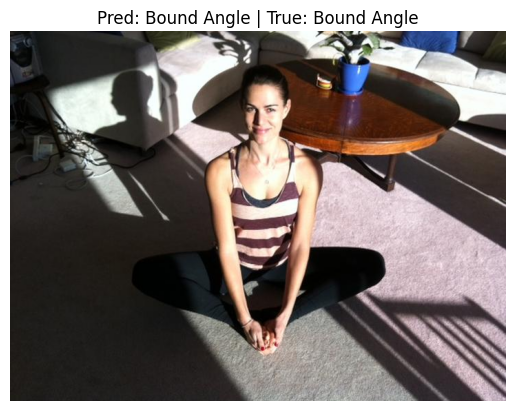

In [7]:
i = 0  # image index
pred = predict_example(i)
filename = img_names[i]


classes = [
    "Bound Angle",
    "Cat",
    "Downward-Facing",
    "Mountain",
    "Tree",
    "Upward Bow",
    "Upward-Facing"
]

print("Example:", filename)
print("Predicted class:", pred, "-", classes[pred])
print("True class:", int(y[i]), "-", classes[int(y[i])])

print("Image file:", img_names[i])

show_image(filename, true_class_idx=int(y[i]), title=f"Pred: {classes[pred]} | True: {classes[int(y[i])]}")

# Pose correction

In [8]:
# basic functions

def angle(a, b, c):
    ba = a - b
    bc = c - b
    cosang = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosang, -1, 1)))

def dist(a, b):
    return np.linalg.norm(a - b)

def vertical_alignment(a, b, tol=0.1):
    return abs(a[0] - b[0]) < tol

def horizontal_alignment(a, b, tol=0.1):
    return abs(a[1] - b[1]) < tol


In [9]:
def check_bound_angle(kp):
    errors = []

    L_sh, R_sh = kp[3], kp[4]
    L_hip, R_hip = kp[13], kp[14]
    L_knee, R_knee = kp[15], kp[16]
    L_heel, R_heel = kp[19], kp[20]

    if dist(L_heel, R_heel) > 0.5:
        errors.append("feet must be close")



    if L_knee[0] >= L_hip[0]:
        errors.append("left knee must be lower than hips")
    if R_knee[0] <= R_hip[0]:
        errors.append("right knee must be lower than hips")

    spine_angle = angle(L_sh, L_hip, L_knee)
    if spine_angle < 150:
        errors.append("spine must be straight")

    return errors


In [10]:
def check_cat(kp):
    errors = []

    L_sh, R_sh = kp[3], kp[4]
    L_hip, R_hip = kp[13], kp[14]
    nose = kp[0]
    L_el, R_el = kp[5], kp[6]
    L_wr, R_wr = kp[7], kp[8]

    if nose[1] < (L_sh[1] + R_sh[1]) / 2:
        errors.append("Head must be lower than shoulders")

    if angle(L_sh, L_el, L_wr) < 100:
        errors.append("left hand must be straight")
    if angle(R_sh, R_el, R_wr) < 100:
        errors.append("right hand must be straight")

    return errors


In [11]:
def check_downward_facing(kp):
    errors = []

    L_sh, R_sh = kp[3], kp[4]
    L_hip, R_hip = kp[13], kp[14]
    L_knee, R_knee = kp[15], kp[16]
    L_ankle, R_ankle = kp[17], kp[18]
    L_el, R_el = kp[5], kp[6]
    L_wr, R_wr = kp[7], kp[8]

    if L_hip[1] < L_sh[1] and R_hip[1] < R_sh[1]:
        errors.append("hips must be higher than shoulders")

    if angle(L_sh, L_el, L_wr) < 100:
        errors.append("left hand must be straight")
    if angle(R_sh, R_el, R_wr) < 100:
        errors.append("right hand must be straight")

    if angle(L_hip, L_knee, L_ankle) < 100:
        errors.append("left leg must be straight")
    if angle(R_hip, R_knee, R_ankle) < 100:
        errors.append("right leg must be straight")

    return errors


In [12]:
def check_mountain(kp):
    errors = []

    L_sh, R_sh = kp[3], kp[4]
    L_hip, R_hip = kp[13], kp[14]
    L_knee, R_knee = kp[15], kp[16]
    L_ankle, R_ankle = kp[17], kp[18]
    L_wr, R_wr = kp[7], kp[8]

    if not vertical_alignment(L_sh, L_hip):
        errors.append("left shoulder is not aligned with hips")
    if not vertical_alignment(R_sh, R_hip):
        errors.append("right shoulder is not aligned with hips")

    if not vertical_alignment(L_hip, L_knee):
        errors.append("left shoulder is not aligned with knee")
    if not vertical_alignment(R_hip, R_knee):
        errors.append("right shoulder is not aligned with knee")

    if angle(L_hip, L_knee, L_ankle) < 170:
        errors.append("left knee must be straight")
    if angle(R_hip, R_knee, R_ankle) < 170:
        errors.append("right knee must be straight")

    return errors


In [13]:
def check_tree(kp):
    errors = []

    L_hip, R_hip = kp[13], kp[14]
    L_knee, R_knee = kp[15], kp[16]
    L_ankle, R_ankle = kp[17], kp[18]
    L_sh, R_sh = kp[3], kp[4]
    L_wr, R_wr = kp[7], kp[8]

    left_support = L_ankle[1] > R_ankle[1] 

    if left_support:
        if angle(R_hip, R_knee, R_ankle) > 120:
            errors.append("right leg must be bent")
    else:
        if angle(L_hip, L_knee, L_ankle) > 120:
            errors.append("left leg must be bent")

    if abs(L_hip[1] - R_hip[1]) > 0.1:
        errors.append("hips must be aligned")

    if L_wr[1] < L_sh[1]:
        errors.append("left hand must be held up")
    if R_wr[1] < R_sh[1]:
        errors.append("right hand must be held up")

    return errors


In [14]:
def check_upward_bow(kp):
    errors = []

    L_sh, R_sh = kp[3], kp[4]
    L_el, R_el = kp[5], kp[6]
    L_wr, R_wr = kp[7], kp[8]
    L_hip, R_hip = kp[13], kp[14]
    L_knee, R_knee = kp[15], kp[16]
    L_ankle, R_ankle = kp[17], kp[18]

    if L_hip[1] > L_sh[1] or R_hip[1] > R_sh[1]:
        errors.append("hips must be higher than shoulders")

    if angle(L_sh, L_el, L_wr) > 100:
        errors.append("left hand must not be straight")
    if angle(R_sh, R_el, R_wr) > 100:
        errors.append("right hand must not be straight")

    if angle(L_hip, L_knee, L_ankle) > 100:
        errors.append("left leg must not be straight")
    if angle(R_hip, R_knee, R_ankle) > 100:
        errors.append("right leg must not be straight")

    return errors


In [15]:
def check_upward_facing(kp):
    errors = []

    L_sh, R_sh = kp[3], kp[4]
    L_el, R_el = kp[5], kp[6]
    L_wr, R_wr = kp[7], kp[8]
    L_hip, R_hip = kp[13], kp[14]
    L_knee, R_knee = kp[15], kp[16]


    if L_hip[1] > L_knee[1] or R_hip[1] > R_knee[1]:
        errors.append("Hips must be higher than knees")

    if angle(L_sh, L_el, L_wr) < 100:
        errors.append("left hand must be straight")
    if angle(R_sh, R_el, R_wr) < 100:
        errors.append("right hand must be straight")

    if not vertical_alignment(L_sh, L_wr):
        errors.append("left shoulder must be aligned with wrist")
    if not vertical_alignment(R_sh, R_wr):
        errors.append("right shoulder must be aligned with wrist")

    return errors


In [16]:
KEYPOINT_NAMES = [
    "nose",
    "left_eye",
    "right_eye",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_index", "right_index",
    "left_thumb", "right_thumb",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
    "left_heel", "right_heel",
    "left_foot_index", "right_foot_index"
]

In [17]:
# rules base

pose_rules = {
    0: check_bound_angle,
    1: check_cat,
    2: check_downward_facing,
    3: check_mountain,
    4: check_tree,
    5: check_upward_bow,
    6: check_upward_facing
}

pred = predict_example(i)
kp = X[i]

errors = pose_rules[pred](kp)


if errors:
    print("Pose correction recommendations:")
    for e in errors:
        print(" -", e)
else:
    print("Pose is correct!")


Pose correction recommendations:
 - spine must be straight


In [18]:
def file_check(img_idx):
    i = img_idx
    pred = predict_example(i)
    filename = img_names[i]

    print("Example:", filename)
    print("Predicted class:", pred, "-", classes[pred])
    print("True class:", int(y[i]), "-", classes[int(y[i])])

    print("Image file:", img_names[i])

    show_image(filename, true_class_idx=int(y[i]), title=f"Pred: {classes[pred]} | True: {classes[int(y[i])]}")

    pred = predict_example(i)
    kp = X[i]

    errors = pose_rules[pred](kp)


    if errors:
        print("Pose correction recommendations:")
        for e in errors:
            print(" -", e)
    else:
        print("Pose is correct!")

In [19]:
kp = X[27]

for idx, name in enumerate(KEYPOINT_NAMES):
    print(f"{idx:2d}: {name:20s} -> {kp[idx]}")


 0: nose                 -> [-8.89481586  7.60967731  0.          0.          0.          0.        ]
 1: left_eye             -> [-9.53677973e+00  7.61135773e+00 -6.41963873e-01  1.68041699e-03
  6.41966073e-01  0.00000000e+00]
 2: right_eye            -> [-9.46281264  7.64915367 -0.56799679  0.03947636  0.56936696  0.        ]
 3: left_shoulder        -> [-8.95371732  4.77347246  0.          0.          0.          0.        ]
 4: right_shoulder       -> [-7.95371732  4.77347246  1.          0.          1.          0.        ]
 5: left_elbow           -> [-12.83383254   5.41236182  -3.88011522   0.63888936   3.93236237
   2.84144658]
 6: right_elbow          -> [-12.60939697   5.0162775   -4.65567965   0.24280504   4.66200678
   2.89075744]
 7: left_wrist           -> [-17.61373327   4.75361687  -4.77990073  -0.65874495   4.82507988
   0.        ]
 8: right_wrist          -> [-16.40171336   4.2525507   -3.7923164   -0.7637268    3.86845477
   0.        ]
 9: left_index           -> [

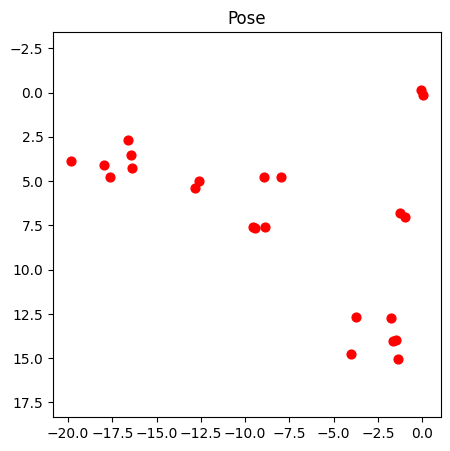

In [20]:
def plot_pose(points, title="Pose"):
    plt.figure(figsize=(5,5))
    plt.scatter(points[:,0], points[:,1], c='red', s=40)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis('equal')
    plt.show()

plot_pose(X[27])

Example: Mountain (20)
Predicted class: 3 - Mountain
True class: 3 - Mountain
Image file: Mountain (20)


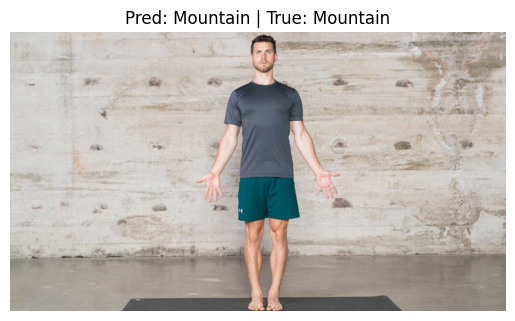

Pose correction recommendations:
 - left shoulder is not aligned with hips
 - right shoulder is not aligned with hips
 - left shoulder is not aligned with knee
 - right shoulder is not aligned with knee
 - left knee must be straight
 - right knee must be straight


In [39]:
file_check(86)